#  Diabetes Prediction — Gradient Boosting + XAI

| | |
|---|---|
| **Student** | Abdallah Saed — 202201933 |
| **Dataset** | BRFSS 2015 Diabetes Health Indicators |
| **Model** | Gradient Boosting Classifier |
| **XAI Techniques** | SHAP · LIME · Permutation Feature Importance · PDP |

---

## 1. Install & Import Libraries

In [32]:
!pip install shap lime scikit-learn pandas numpy matplotlib seaborn imbalanced-learn -q

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from imblearn.over_sampling import SMOTE
import shap
import lime
import lime.lime_tabular

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid', palette='Set2')

print('All libraries imported successfully!')

All libraries imported successfully!


---
##  2. Load Dataset

In [34]:
df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')

print(f'Dataset Shape : {df.shape}')
print(f'Features      : {df.shape[1] - 1}')
print(f'Samples       : {df.shape[0]:,}')
print(f'Missing Values: {df.isnull().sum().sum()}')
df.head()

Dataset Shape : (58478, 22)
Features      : 21
Samples       : 58,478
Missing Values: 2


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


---
##  3. Exploratory Data Analysis (EDA)

In [35]:
print('='*55)
print('DATASET INFORMATION')
print('='*55)
df.info()
print()
df.describe().T

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58478 entries, 0 to 58477
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       58478 non-null  float64
 1   HighBP                58478 non-null  float64
 2   HighChol              58478 non-null  float64
 3   CholCheck             58478 non-null  float64
 4   BMI                   58478 non-null  float64
 5   Smoker                58478 non-null  float64
 6   Stroke                58478 non-null  float64
 7   HeartDiseaseorAttack  58478 non-null  float64
 8   PhysActivity          58478 non-null  float64
 9   Fruits                58478 non-null  float64
 10  Veggies               58478 non-null  float64
 11  HvyAlcoholConsump     58478 non-null  float64
 12  AnyHealthcare         58478 non-null  float64
 13  NoDocbcCost           58478 non-null  float64
 14  GenHlth               58478 non-null  float64
 15 

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,58478.0,0.136462,0.343281,0.0,0.0,0.0,0.0,1.0
HighBP,58478.0,0.424399,0.494256,0.0,0.0,0.0,1.0,1.0
HighChol,58478.0,0.422552,0.493970,0.0,0.0,0.0,1.0,1.0
CholCheck,58478.0,0.963456,0.187640,0.0,1.0,1.0,1.0,1.0
BMI,58478.0,27.888573,6.096743,12.0,24.0,27.0,31.0,96.0
Smoker,58478.0,0.441807,0.496606,0.0,0.0,0.0,1.0,1.0
Stroke,58478.0,0.041725,0.199962,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,58478.0,0.089812,0.285914,0.0,0.0,0.0,0.0,1.0
PhysActivity,58478.0,0.774667,0.417805,0.0,1.0,1.0,1.0,1.0
Fruits,58478.0,0.645935,0.478233,0.0,0.0,1.0,1.0,1.0


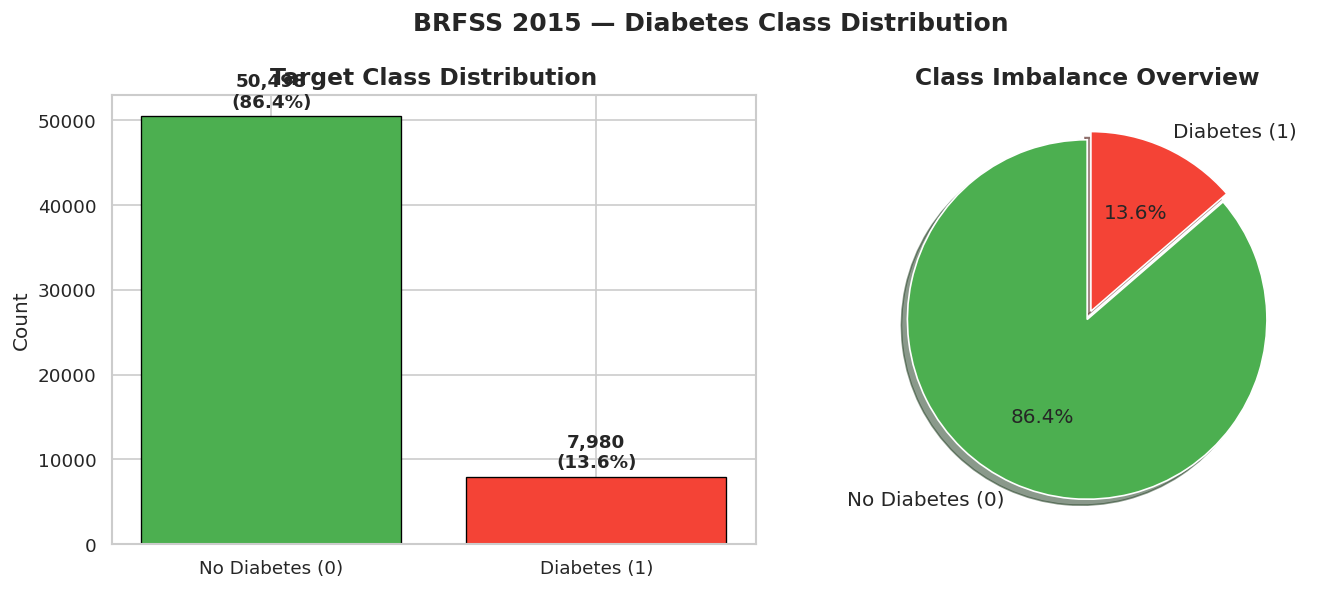

In [36]:
# Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
counts = df['Diabetes_binary'].value_counts()
labels = ['No Diabetes (0)', 'Diabetes (1)']
colors = ['#4CAF50', '#F44336']

axes[0].bar(labels, counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Target Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')

axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, explode=(0, 0.05), shadow=True,
            textprops={'fontsize': 12})
axes[1].set_title('Class Imbalance Overview', fontsize=14, fontweight='bold')

plt.suptitle('BRFSS 2015 — Diabetes Class Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('gb_01_class_distribution.png', bbox_inches='tight')
plt.show()

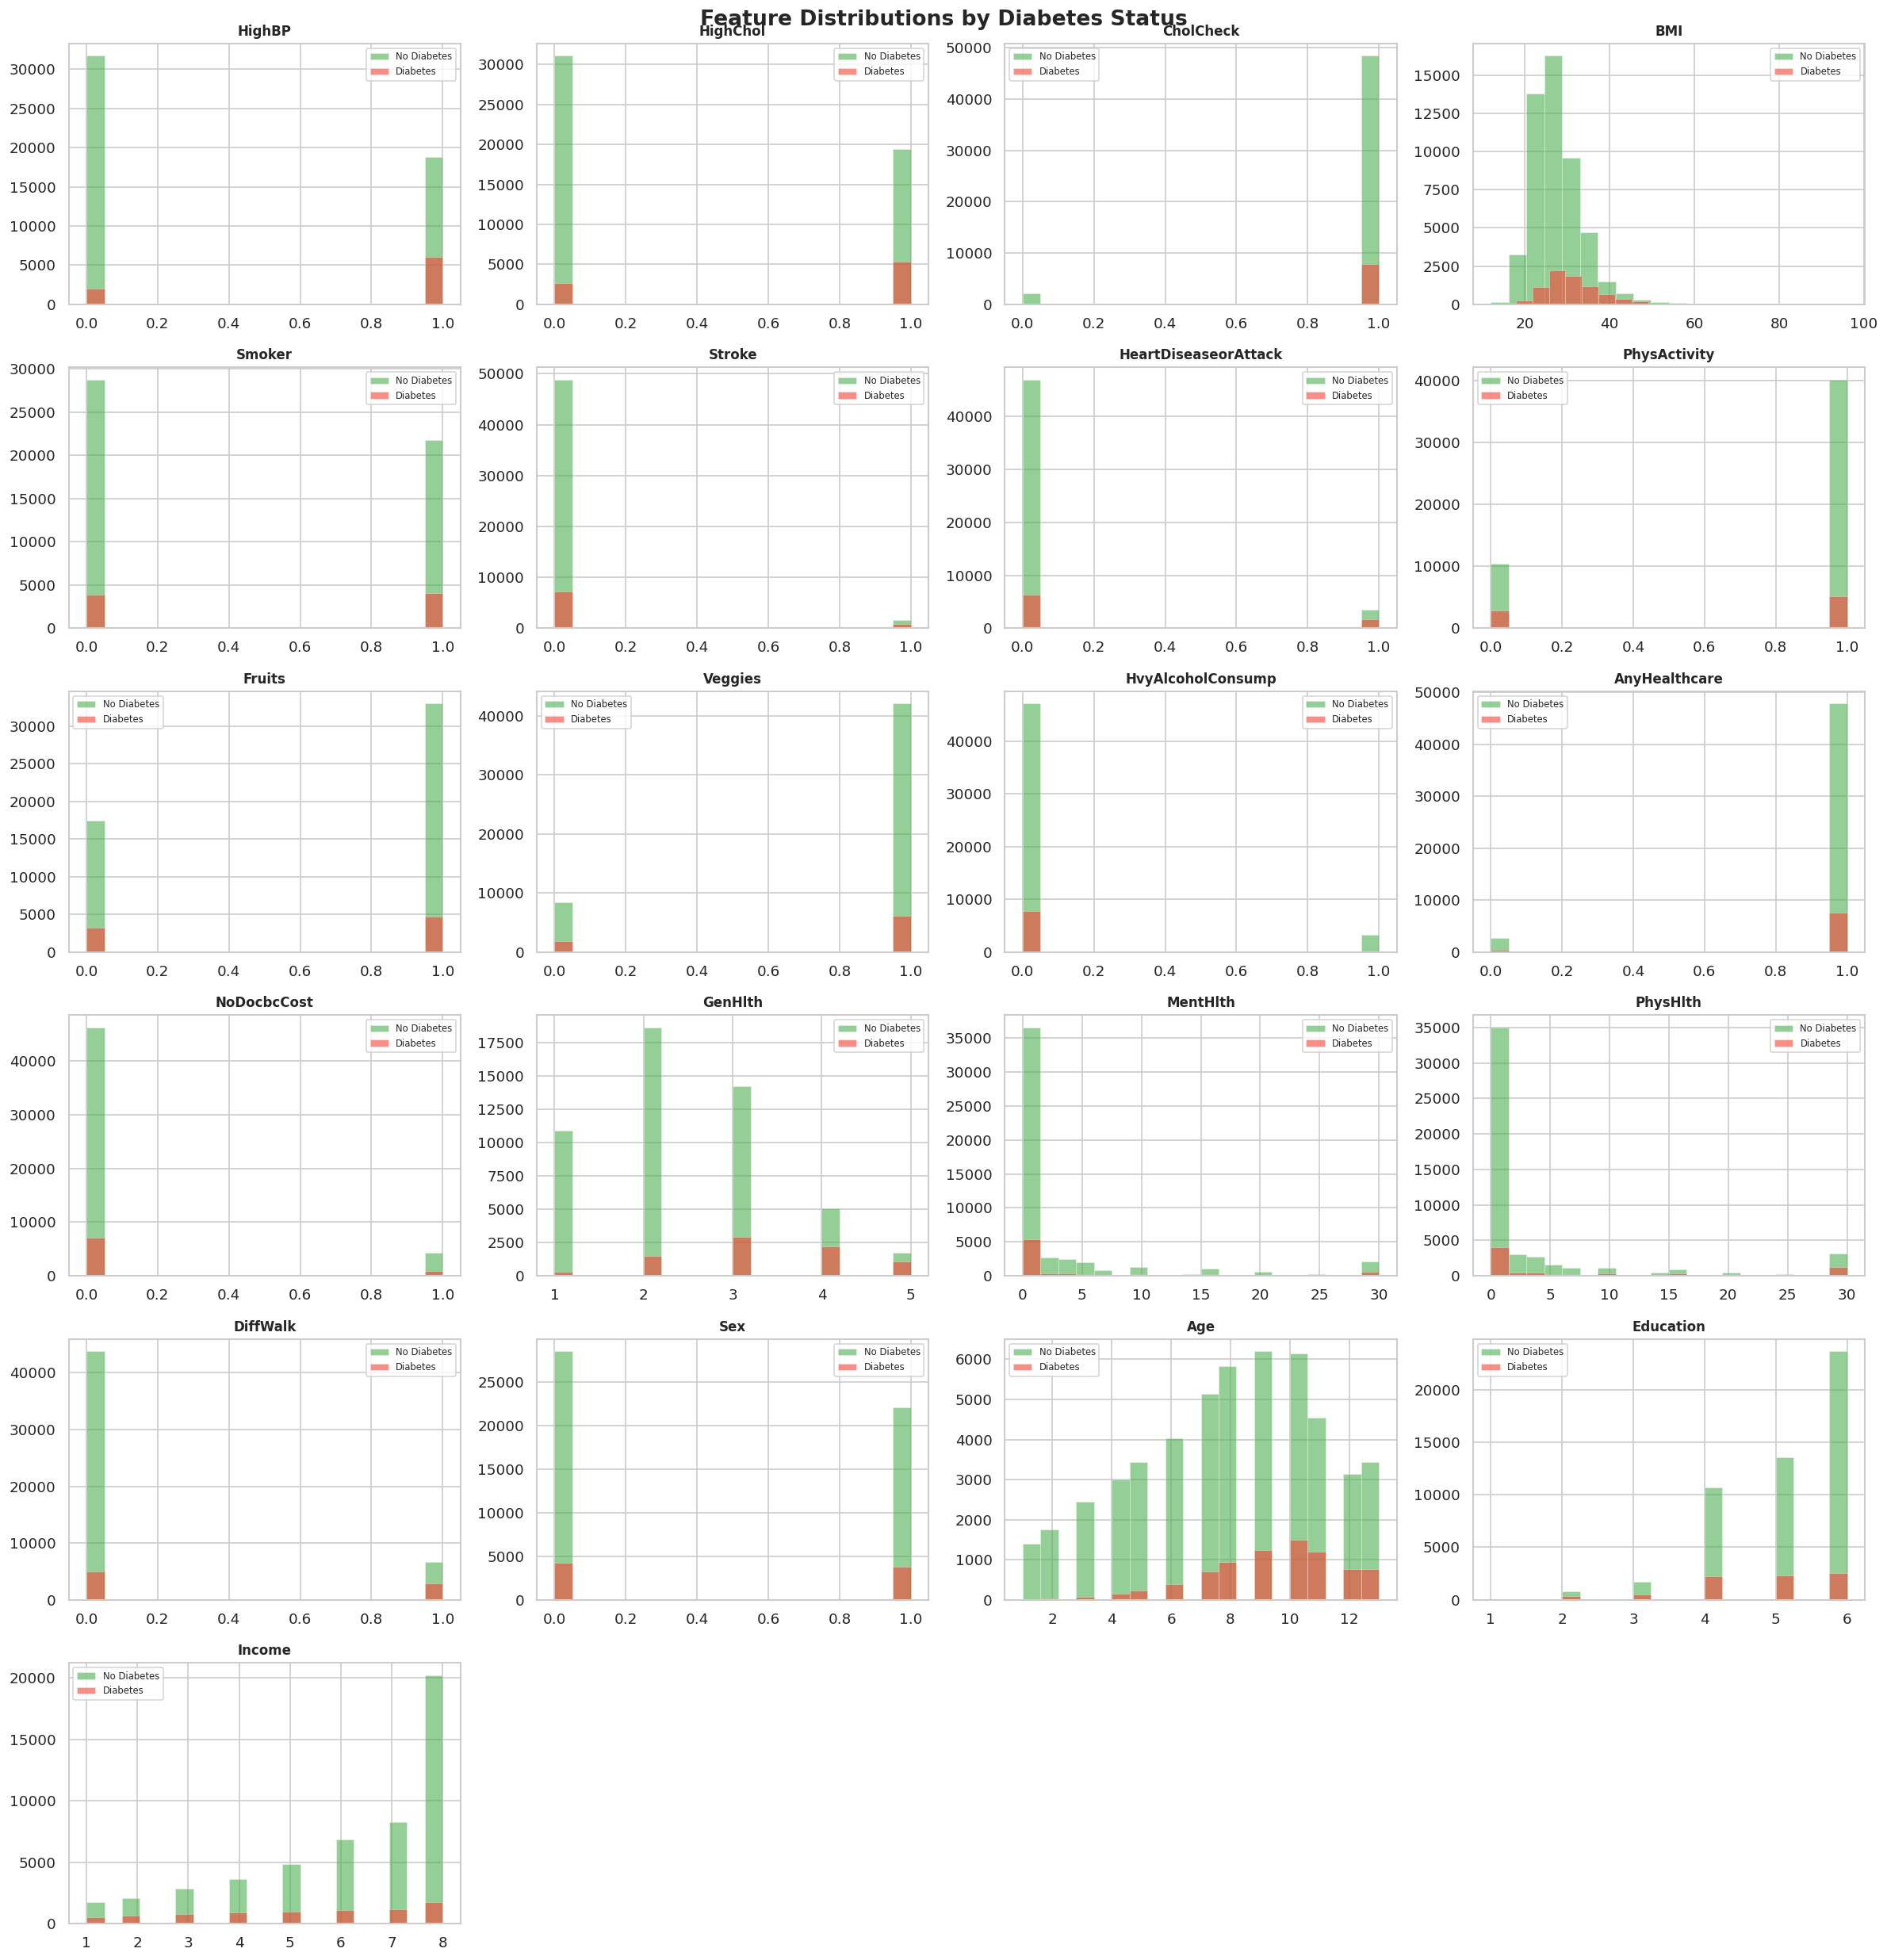

In [37]:
# Feature Distributions
features = df.columns.drop('Diabetes_binary')
n_cols = 4
n_rows = int(np.ceil(len(features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
axes = axes.flatten()

for i, feat in enumerate(features):
    for val, color, label in zip([0,1], ['#4CAF50','#F44336'], ['No Diabetes','Diabetes']):
        axes[i].hist(df[df['Diabetes_binary']==val][feat],
                     bins=20, alpha=0.6, color=color, label=label,
                     edgecolor='white', linewidth=0.3)
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by Diabetes Status', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('gb_02_feature_distributions.png', bbox_inches='tight')
plt.show()

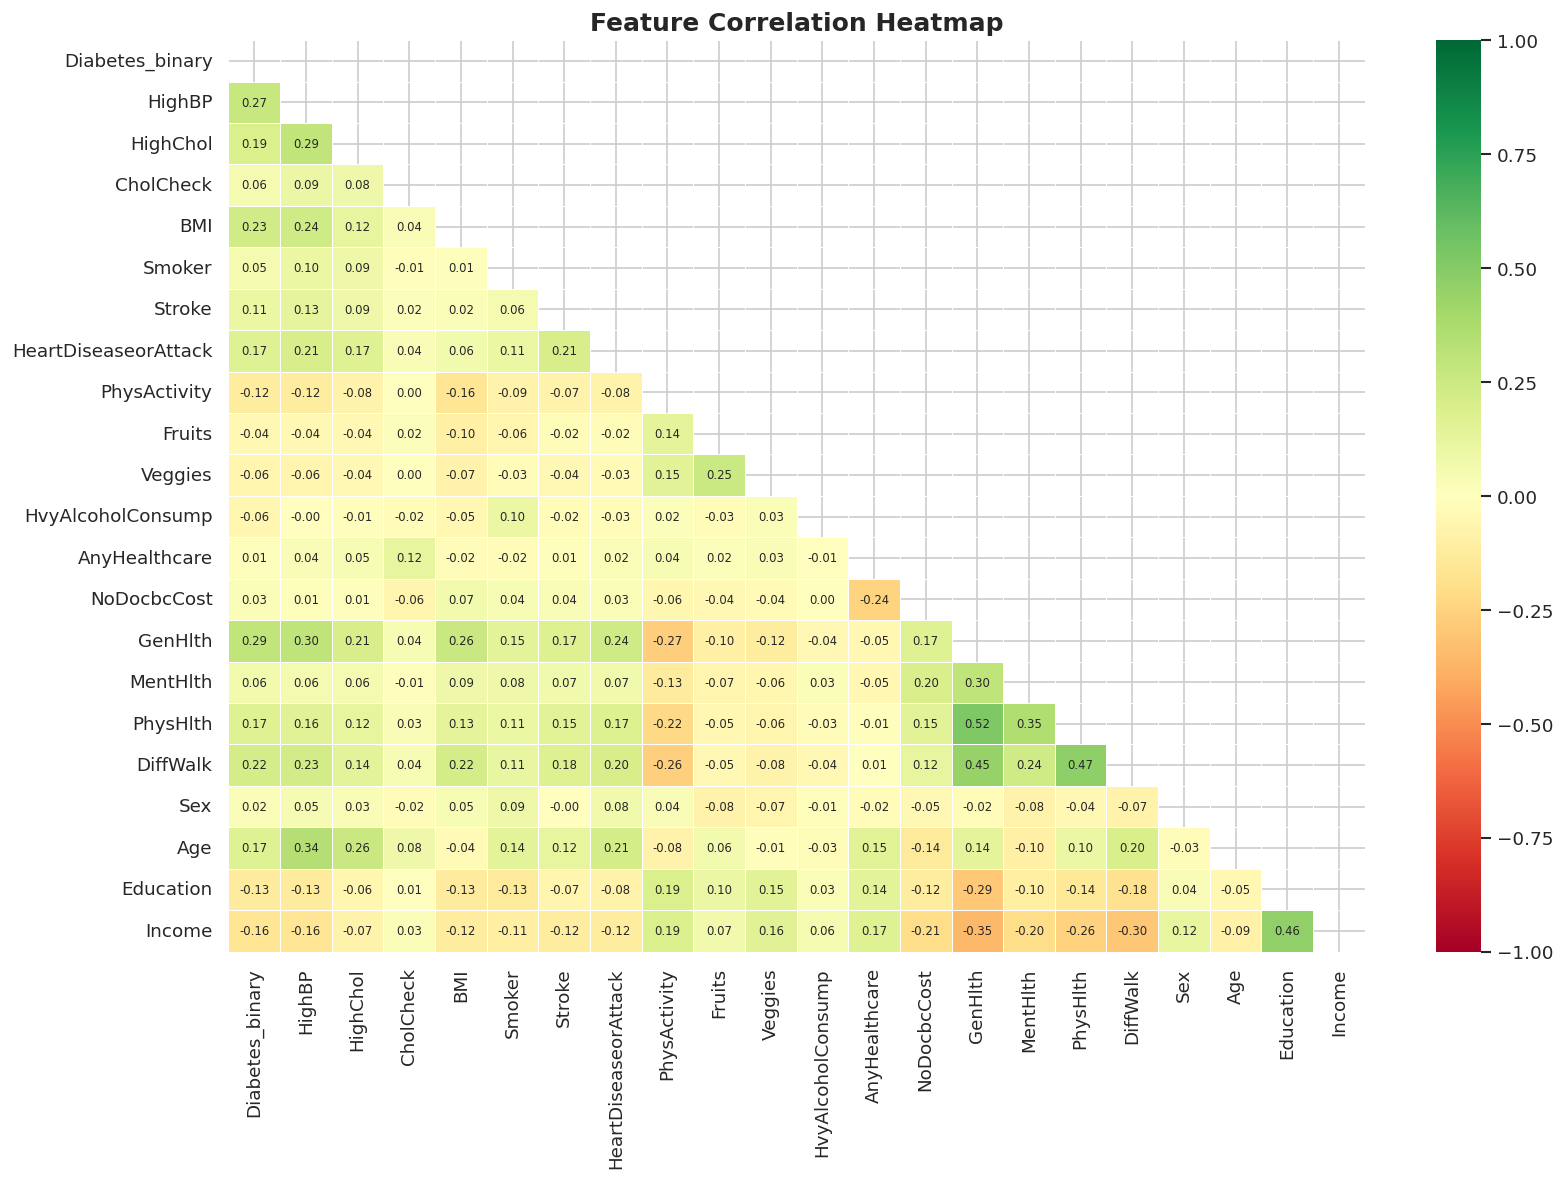

In [38]:
# Correlation Heatmap
plt.figure(figsize=(14, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, linecolor='white', annot_kws={'size': 7},
            vmin=-1, vmax=1, center=0)
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('gb_03_correlation_heatmap.png', bbox_inches='tight')
plt.show()

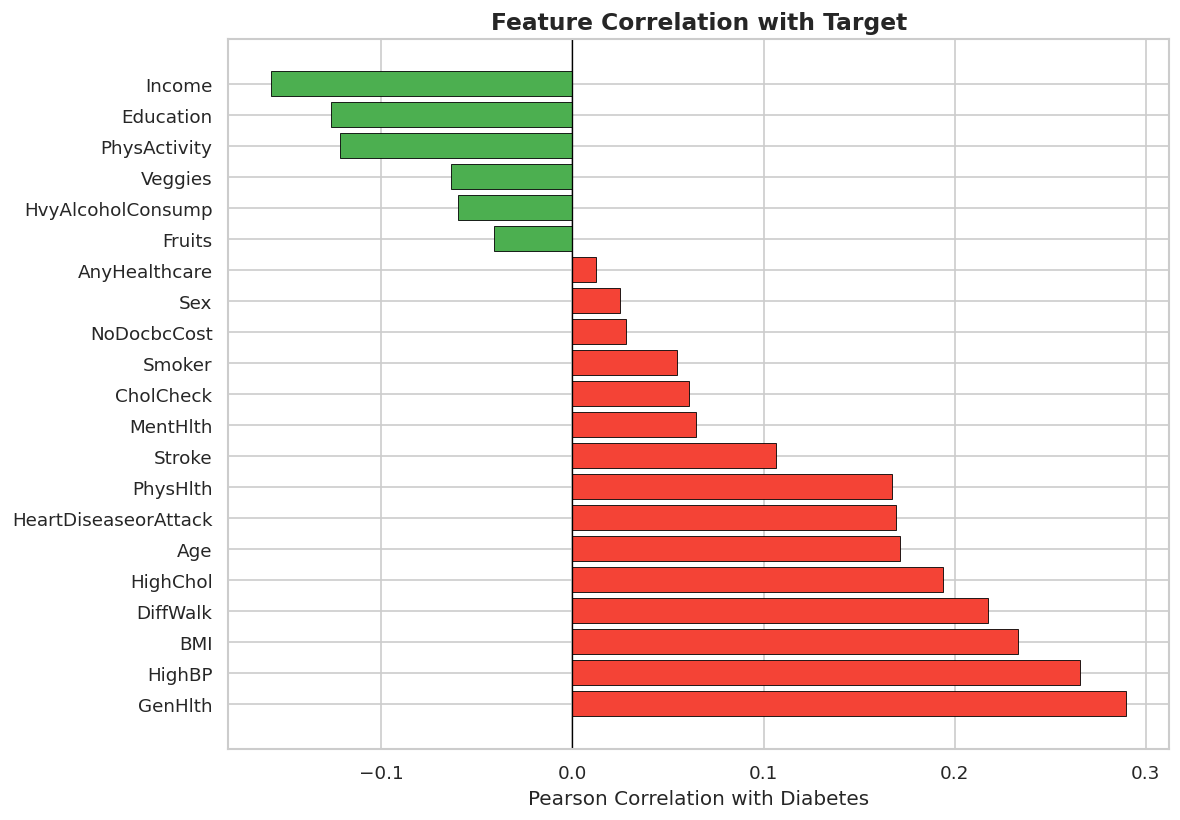

In [39]:
# Correlation with Target
target_corr = df.corr()['Diabetes_binary'].drop('Diabetes_binary').sort_values(ascending=False)
plt.figure(figsize=(10, 7))
colors_bar = ['#F44336' if x > 0 else '#4CAF50' for x in target_corr.values]
plt.barh(target_corr.index, target_corr.values, color=colors_bar, edgecolor='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Pearson Correlation with Diabetes', fontsize=12)
plt.title('Feature Correlation with Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('gb_04_target_correlation.png', bbox_inches='tight')
plt.show()

---
##  4. Data Preprocessing

In [40]:
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary'].astype(int)
feature_names = list(X.columns)

print(f'Features : {X.shape[1]}')
print(f'Samples  : {X.shape[0]:,}')
print(f'Target   : {y.value_counts().to_dict()}')

Features : 21
Samples  : 58,478
Target   : {0: 50498, 1: 7980}


In [41]:
from sklearn.impute import SimpleImputer

# Remove duplicates before any processing
df.drop_duplicates(inplace=True)

# Re-define X and y after dedup
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"].astype(int)
feature_names = list(X.columns)

# Impute missing values with median (robust for medical data)
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

# Stratified split to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {X_train.shape[0]:,}")
print(f"Test size  : {X_test.shape[0]:,}")
print(f"Missing values after imputation: {pd.DataFrame(X_imputed).isnull().sum().sum()}")


Train size : 44,589
Test size  : 11,148
Missing values after imputation: 0


StandardScaler applied
Before SMOTE -> 0: 38,220  |  1: 6,369
After  SMOTE -> 0: 38,220  |  1: 38,220


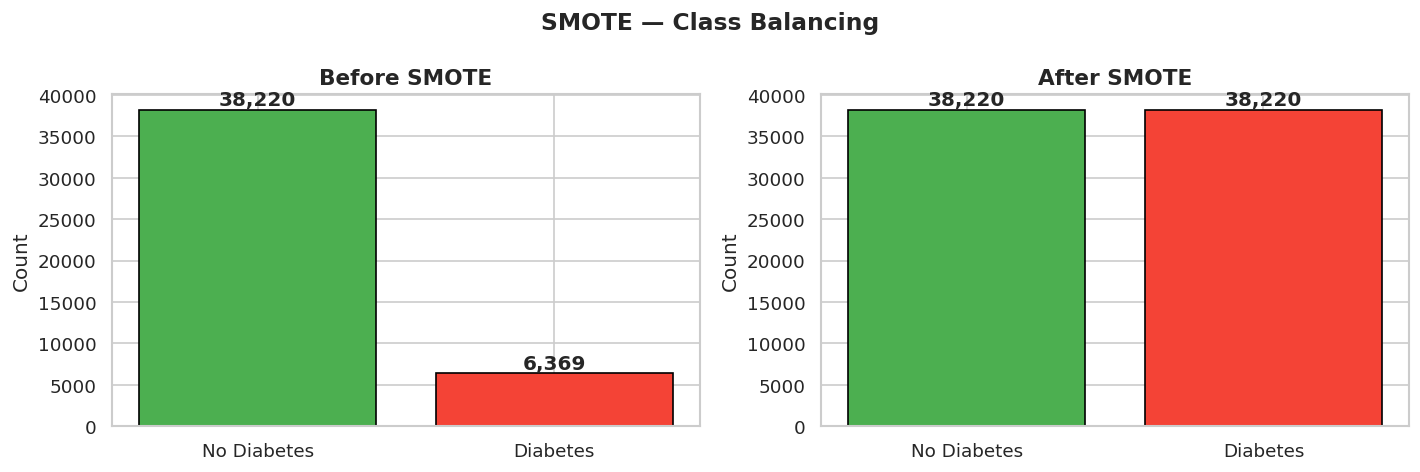

In [42]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("StandardScaler applied")

# SMOTE to balance classes — applied only on training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE -> 0: {sum(y_train==0):,}  |  1: {sum(y_train==1):,}")
print(f"After  SMOTE -> 0: {sum(y_train_res==0):,}  |  1: {sum(y_train_res==1):,}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y_data, title in zip(axes, [y_train, y_train_res], ["Before SMOTE", "After SMOTE"]):
    cnts = pd.Series(y_data).value_counts()
    ax.bar(["No Diabetes", "Diabetes"], cnts.values,
           color=["#4CAF50", "#F44336"], edgecolor="black")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel("Count")
    for i, v in enumerate(cnts.values):
        ax.text(i, v + 500, f"{v:,}", ha="center", fontweight="bold")
plt.suptitle("SMOTE — Class Balancing", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("gb_05_smote.png", bbox_inches="tight")
plt.show()


In [43]:
# Preprocessing complete — X_train_res and y_train_res are ready for training
print(f"Final training set shape : {X_train_res.shape}")
print(f"Final test set shape     : {X_test_scaled.shape}")


Final training set shape : (76440, 21)
Final test set shape     : (11148, 21)


---
##  5. Gradient Boosting Model

In [44]:
# Tuned hyperparameters to improve Recall and F1 on imbalanced medical data
gb_model = GradientBoostingClassifier(
    n_estimators      = 300,
    learning_rate     = 0.05,
    max_depth         = 5,
    subsample         = 0.8,
    min_samples_split = 10,
    min_samples_leaf  = 5,
    max_features      = "sqrt",
    random_state      = 42
)

print("Training Gradient Boosting... (~2-3 min)")
gb_model.fit(X_train_res, y_train_res)
print("Gradient Boosting Trained!")


Training Gradient Boosting... (~2-3 min)
Gradient Boosting Trained!


In [45]:
from sklearn.metrics import precision_recall_curve

gb_pred_proba = gb_model.predict_proba(X_test_scaled)[:, 1]

# Use F-beta with beta=0.6 to weight Precision more than Recall
# beta < 1 penalises low Precision harder than low Recall
beta = 1.5
precisions, recalls, thresholds = precision_recall_curve(y_test, gb_pred_proba)
fbeta_scores = (1 + beta**2) * (precisions * recalls) / ((beta**2 * precisions) + recalls + 1e-9)
best_idx       = fbeta_scores.argmax()
best_threshold = thresholds[best_idx]
print(f"Optimal threshold (F-beta b=0.6): {best_threshold:.4f}")

# Additionally find the crossing point where Precision == Recall
cross_idx = np.argmin(np.abs(precisions[:-1] - recalls[:-1]))
cross_threshold = thresholds[cross_idx]
print(f"Precision=Recall crossing threshold: {cross_threshold:.4f}")

# Use the F-beta threshold as the final threshold
gb_pred = (gb_pred_proba >= best_threshold).astype(int)

gb_acc  = accuracy_score(y_test, gb_pred)
gb_auc  = roc_auc_score(y_test, gb_pred_proba)
gb_f1   = f1_score(y_test, gb_pred)
gb_prec = precision_score(y_test, gb_pred)
gb_rec  = recall_score(y_test, gb_pred)

print("=" * 50)
print("  GRADIENT BOOSTING RESULTS")
print("=" * 50)
print(f"  Accuracy  : {gb_acc:.4f}")
print(f"  AUC-ROC   : {gb_auc:.4f}")
print(f"  F1 Score  : {gb_f1:.4f}")
print(f"  Precision : {gb_prec:.4f}")
print(f"  Recall    : {gb_rec:.4f}")
print("=" * 50)
print()
print(classification_report(y_test, gb_pred, target_names=["No Diabetes", "Diabetes"]))


Optimal threshold (F-beta b=0.6): 0.2439
Precision=Recall crossing threshold: 0.4218
  GRADIENT BOOSTING RESULTS
  Accuracy  : 0.7470
  AUC-ROC   : 0.8180
  F1 Score  : 0.4547
  Precision : 0.3284
  Recall    : 0.7387

              precision    recall  f1-score   support

 No Diabetes       0.95      0.75      0.84      9556
    Diabetes       0.33      0.74      0.45      1592

    accuracy                           0.75     11148
   macro avg       0.64      0.74      0.64     11148
weighted avg       0.86      0.75      0.78     11148



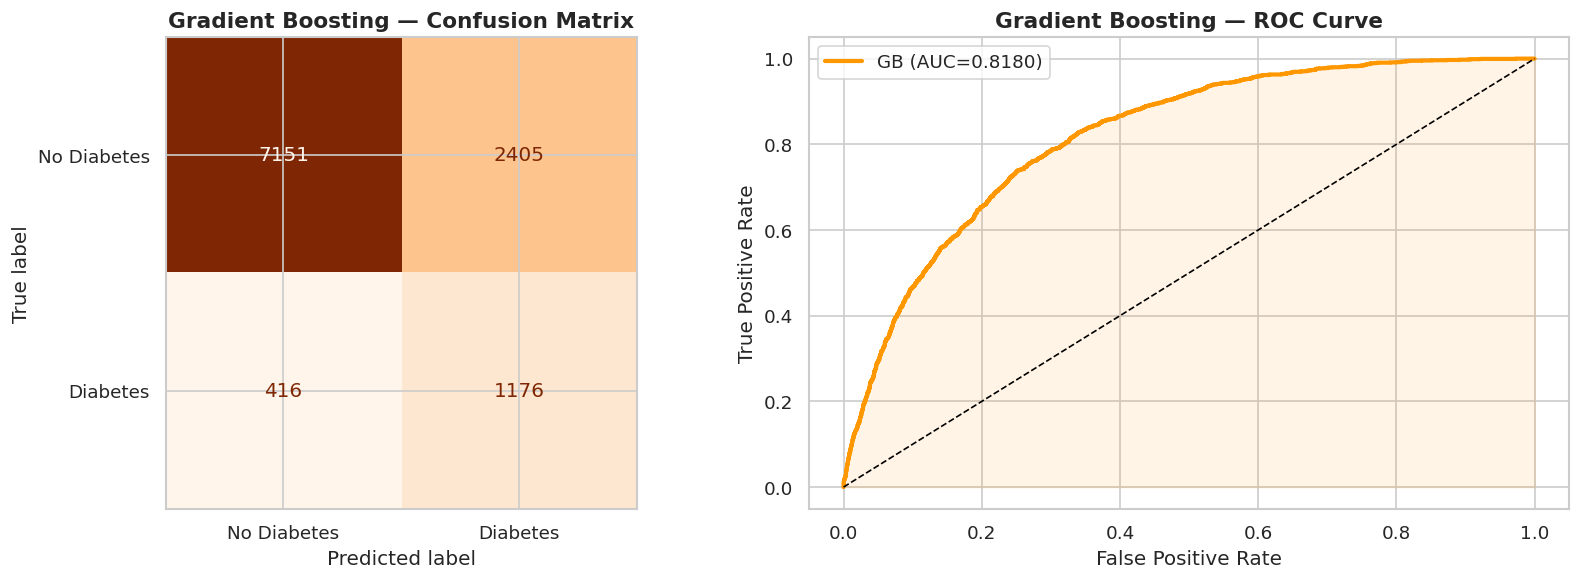

In [46]:
# Confusion Matrix & ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, gb_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Diabetes','Diabetes']).plot(
    ax=axes[0], colorbar=False, cmap='Oranges')
axes[0].set_title('Gradient Boosting — Confusion Matrix', fontsize=13, fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, gb_pred_proba)
axes[1].plot(fpr, tpr, color='#FF9800', linewidth=2.5,
             label=f'GB (AUC={gb_auc:.4f})')
axes[1].plot([0,1],[0,1],'k--', linewidth=1)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#FF9800')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('Gradient Boosting — ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig('gb_06_evaluation.png', bbox_inches='tight')
plt.show()

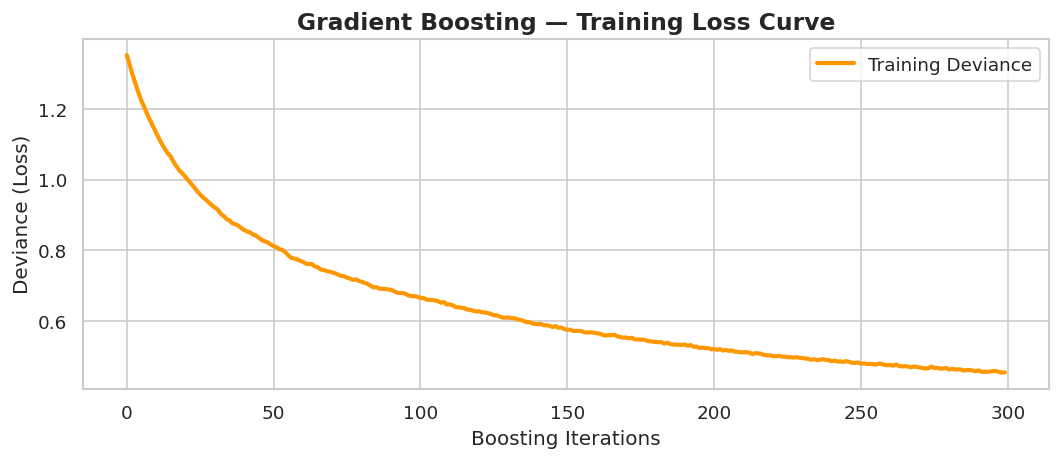

In [47]:
# Training Loss Curve
plt.figure(figsize=(9, 4))
plt.plot(gb_model.train_score_, color='#FF9800', linewidth=2.5, label='Training Deviance')
plt.xlabel('Boosting Iterations', fontsize=12)
plt.ylabel('Deviance (Loss)', fontsize=12)
plt.title('Gradient Boosting — Training Loss Curve', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('gb_07_loss_curve.png', bbox_inches='tight')
plt.show()

---
#  Explainable AI (XAI)
## XAI Technique 1 — SHAP

In [48]:
print('🔍 Computing SHAP values (TreeExplainer)...')
X_test_df    = pd.DataFrame(X_test_scaled, columns=feature_names)
shap_sample  = X_test_df.sample(n=500, random_state=42)

gb_explainer   = shap.TreeExplainer(gb_model)
gb_shap_values = gb_explainer.shap_values(shap_sample)
print(f' SHAP values computed! Shape: {gb_shap_values.shape}')

🔍 Computing SHAP values (TreeExplainer)...
 SHAP values computed! Shape: (500, 21)


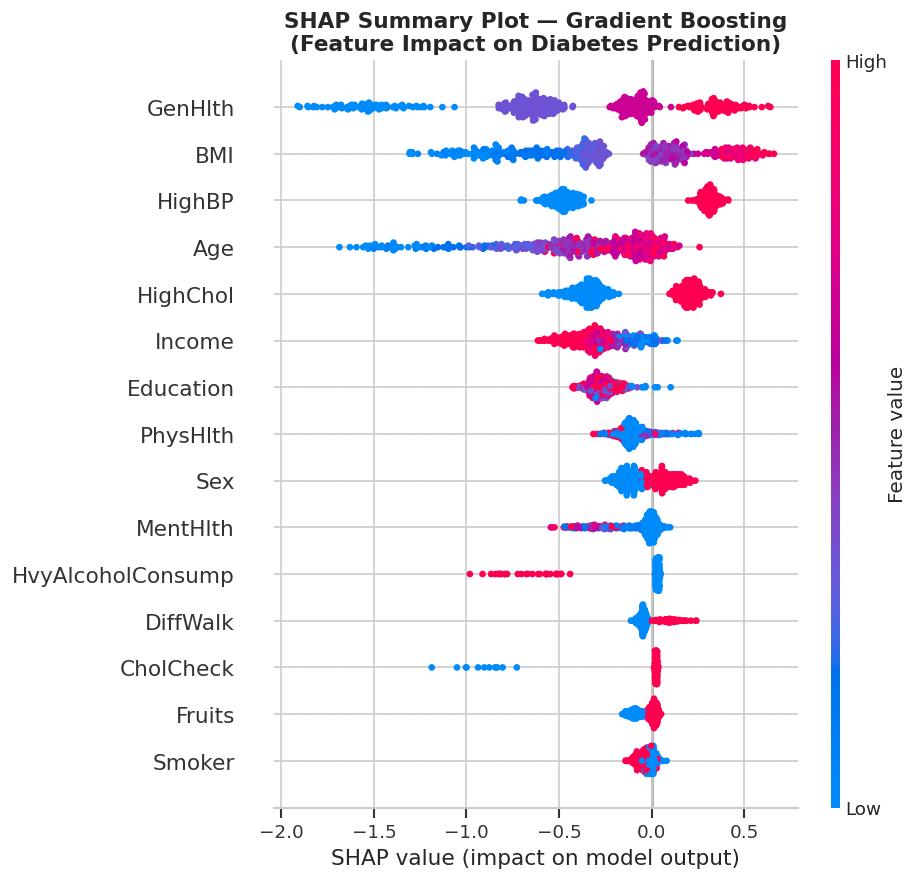

In [49]:
# SHAP Beeswarm
plt.figure(figsize=(10, 7))
shap.summary_plot(gb_shap_values, shap_sample,
                  feature_names=feature_names,
                  plot_type='dot', show=False, max_display=15)
plt.title('SHAP Summary Plot — Gradient Boosting\n(Feature Impact on Diabetes Prediction)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gb_08_shap_beeswarm.png', bbox_inches='tight')
plt.show()

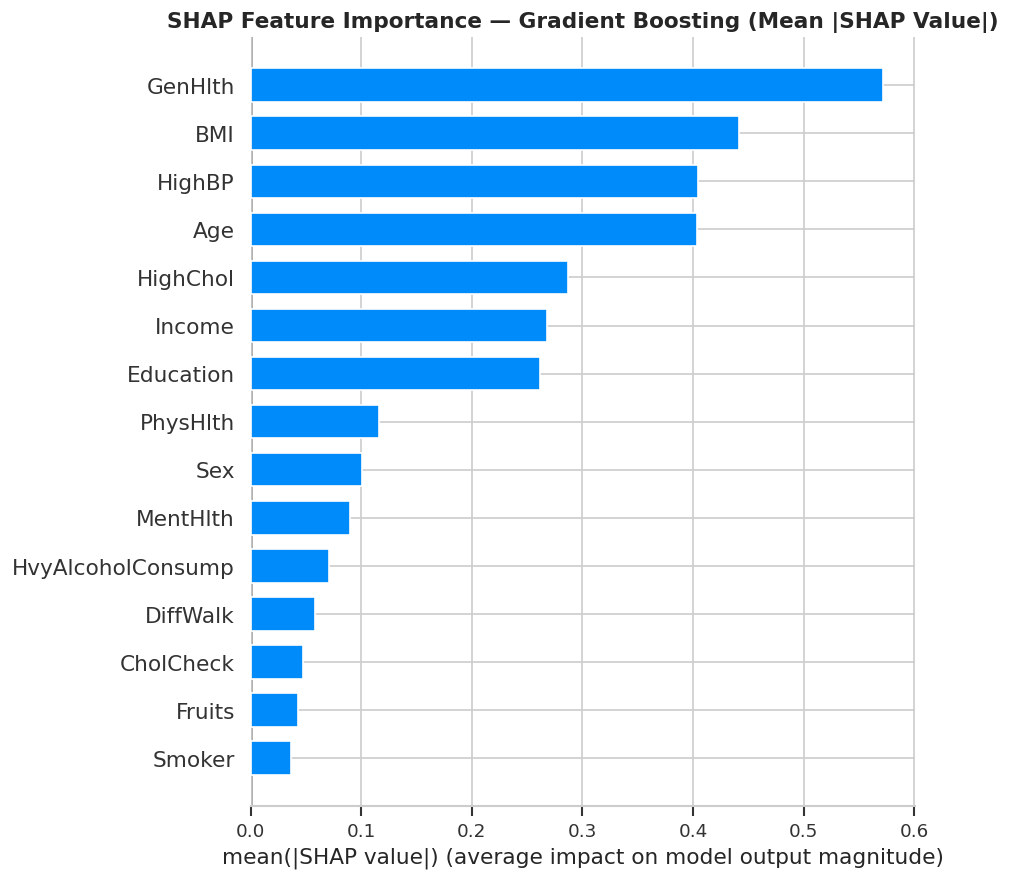

In [50]:
# SHAP Bar Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(gb_shap_values, shap_sample,
                  feature_names=feature_names,
                  plot_type='bar', show=False, max_display=15)
plt.title('SHAP Feature Importance — Gradient Boosting (Mean |SHAP Value|)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gb_09_shap_bar.png', bbox_inches='tight')
plt.show()

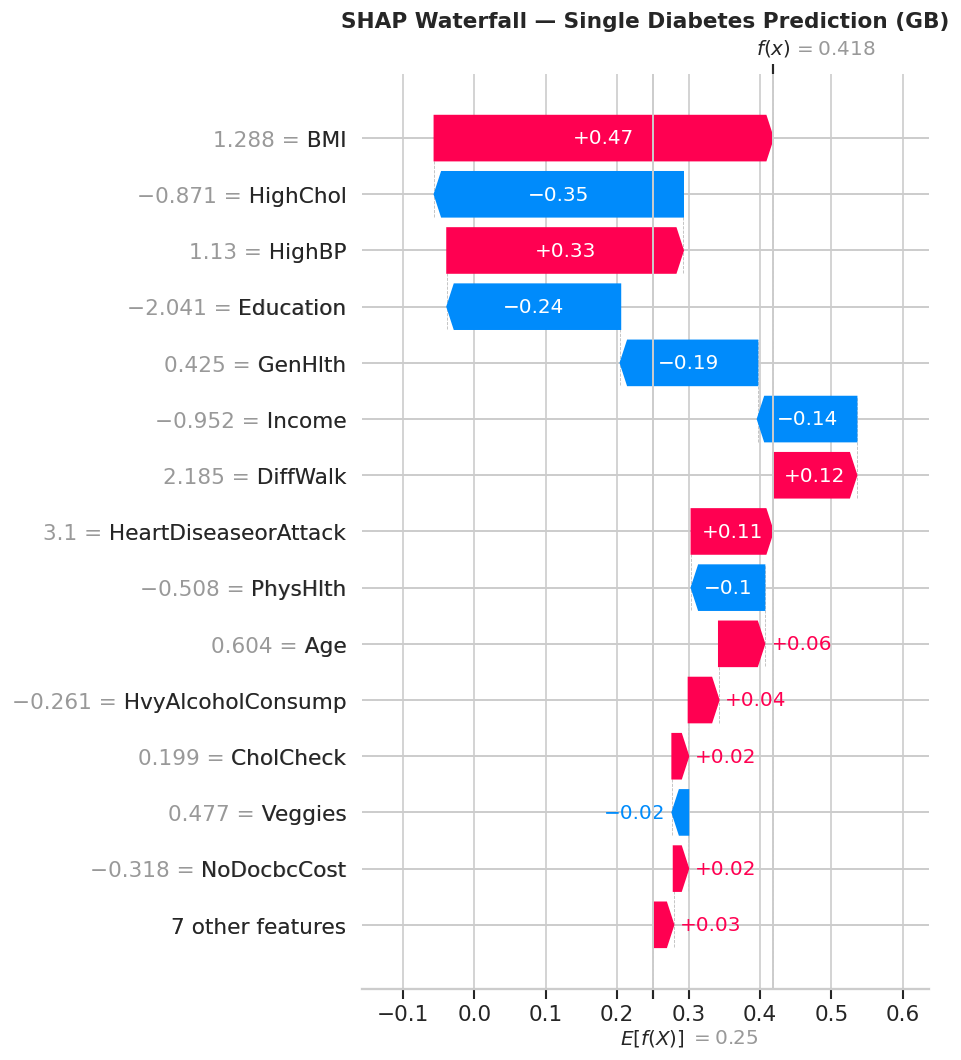

In [51]:
# SHAP Waterfall — Single Diabetes Instance
explainer_obj = shap.TreeExplainer(gb_model)
pos_in_sample = shap_sample.index[gb_model.predict(shap_sample) == 1][0]
sv = explainer_obj(shap_sample.loc[[pos_in_sample]])

plt.figure(figsize=(10, 6))
shap.plots.waterfall(sv[0], show=False, max_display=15)
plt.title('SHAP Waterfall — Single Diabetes Prediction (GB)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gb_10_shap_waterfall.png', bbox_inches='tight')
plt.show()

<Figure size 1080x720 with 0 Axes>

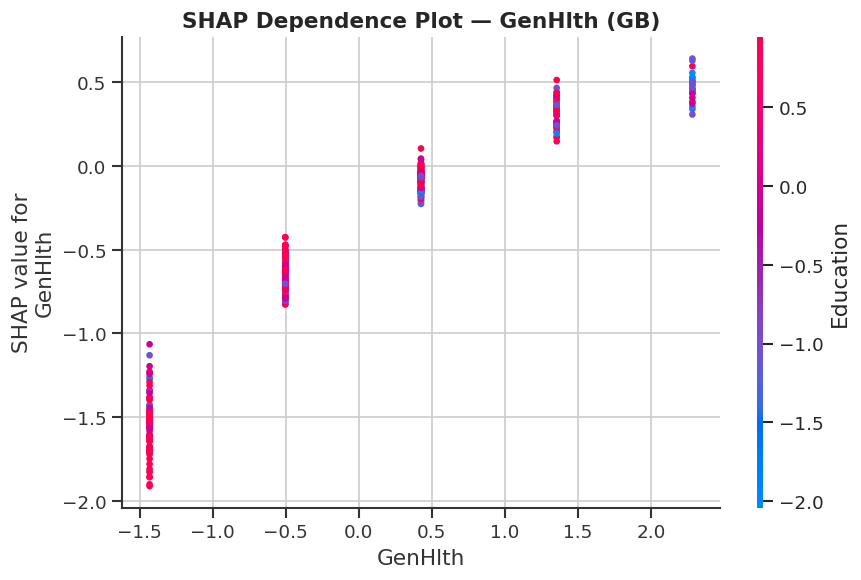

In [52]:
# SHAP Dependence Plot — Top Feature
top_shap_feature = pd.Series(
    np.abs(gb_shap_values).mean(axis=0),
    index=feature_names
).idxmax()

plt.figure(figsize=(9, 6))
shap.dependence_plot(
    top_shap_feature, gb_shap_values, shap_sample,
    feature_names=feature_names, show=False
)
plt.title(f'SHAP Dependence Plot — {top_shap_feature} (GB)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gb_11_shap_dependence.png', bbox_inches='tight')
plt.show()

---
## XAI Technique 2 — LIME

In [53]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_res,
    feature_names = feature_names,
    class_names   = ['No Diabetes', 'Diabetes'],
    mode          = 'classification',
    random_state  = 42
)
print(' LIME Explainer initialized!')

 LIME Explainer initialized!


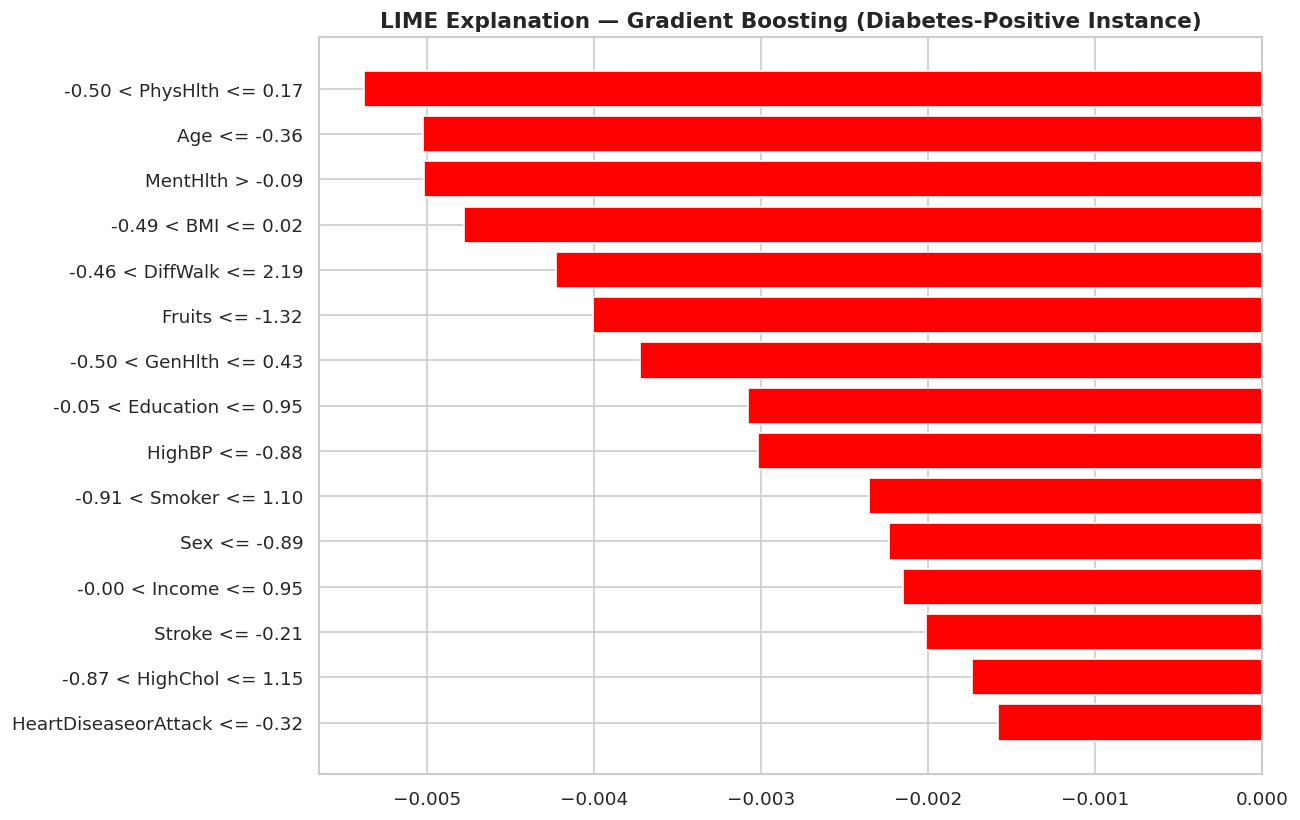

Predicted Probability: [0.8675421 0.1324579]
True Label: 1


In [54]:
# LIME — Single Diabetes-positive instance
pos_idx  = np.where(y_test.values == 1)[0][0]
instance = X_test_scaled[pos_idx]

lime_exp = lime_explainer.explain_instance(
    data_row   = instance,
    predict_fn = gb_model.predict_proba,
    num_features=15,
    num_samples=1000
)

fig = lime_exp.as_pyplot_figure(label=1)
fig.set_size_inches(11, 7)
plt.title('LIME Explanation — Gradient Boosting (Diabetes-Positive Instance)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gb_12_lime_single.png', bbox_inches='tight')
plt.show()
print(f'Predicted Probability: {gb_model.predict_proba([instance])[0]}')
print(f'True Label: {y_test.values[pos_idx]}')

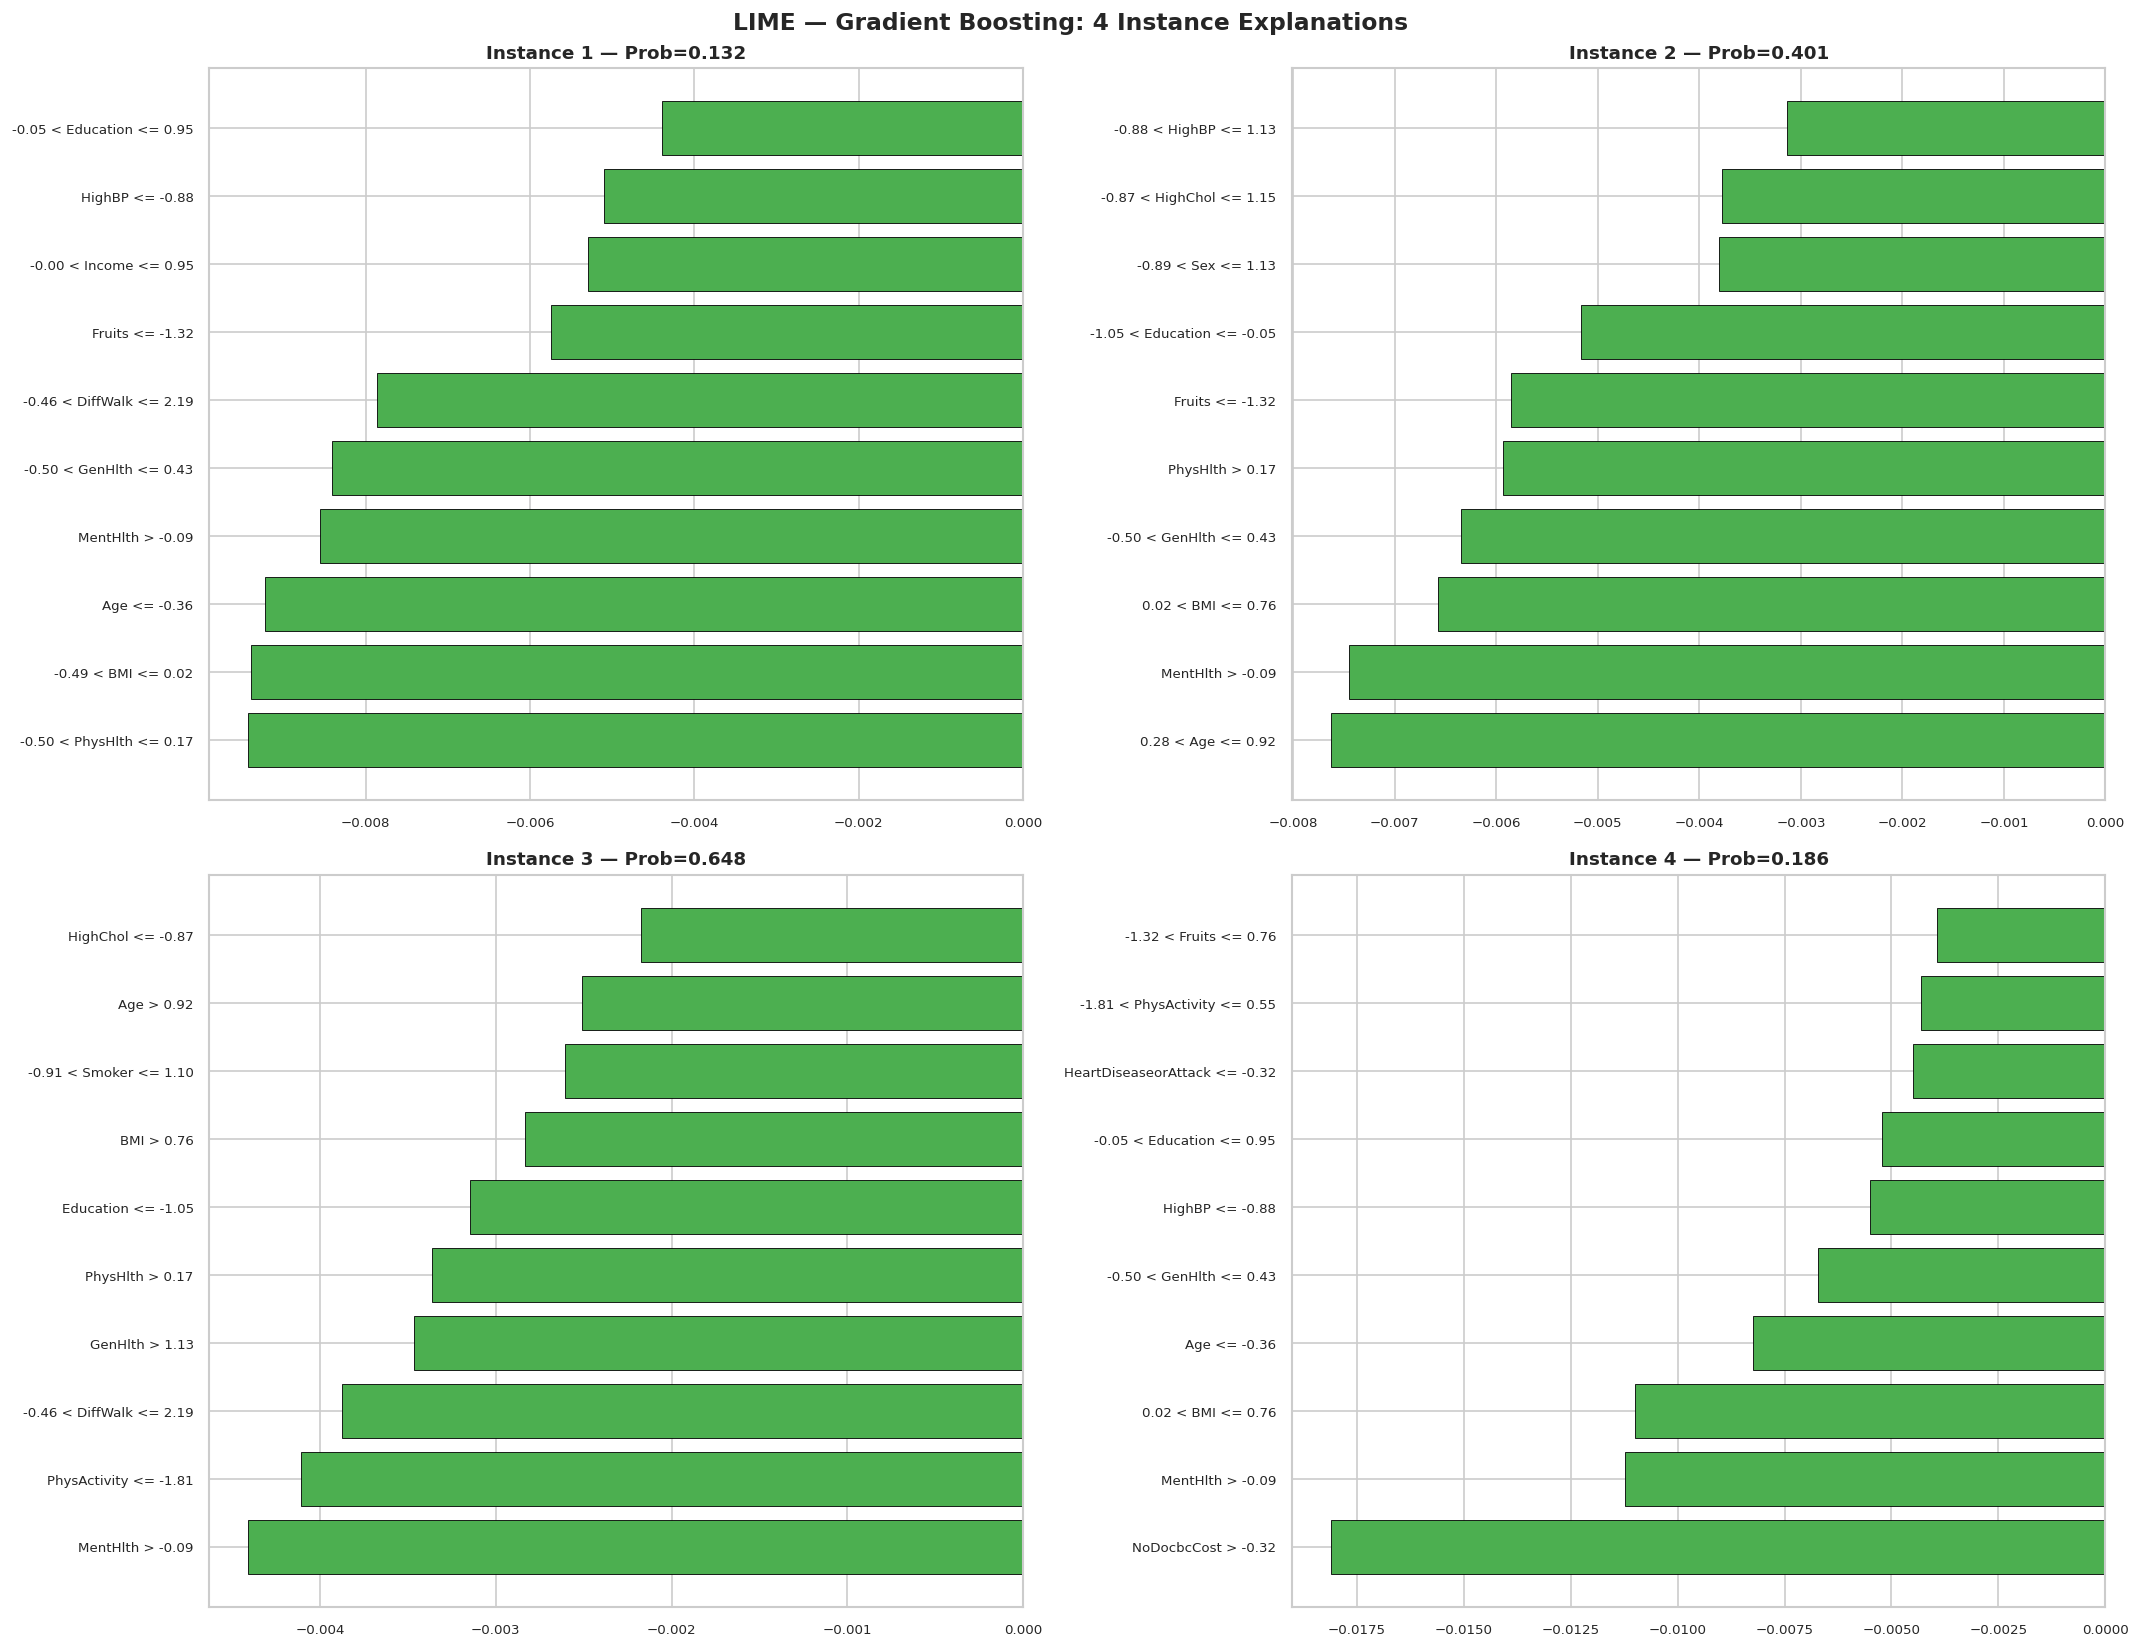

In [55]:
# LIME — 4 Instances Comparison
pos_indices = np.where(y_test.values == 1)[0][:4]
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, idx in enumerate(pos_indices):
    inst = X_test_scaled[idx]
    exp  = lime_explainer.explain_instance(
        data_row=inst, predict_fn=gb_model.predict_proba,
        num_features=10, num_samples=500
    )
    vals    = exp.as_list(label=1)
    feats_l = [v[0] for v in vals]
    weights = [v[1] for v in vals]
    clrs    = ['#F44336' if w > 0 else '#4CAF50' for w in weights]
    axes[i].barh(feats_l, weights, color=clrs, edgecolor='black', linewidth=0.5)
    axes[i].axvline(0, color='black', linewidth=0.8)
    axes[i].set_title(
        f'Instance {i+1} — Prob={gb_model.predict_proba([inst])[0][1]:.3f}',
        fontsize=11, fontweight='bold')
    axes[i].tick_params(labelsize=8)

plt.suptitle('LIME — Gradient Boosting: 4 Instance Explanations',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('gb_13_lime_multi.png', bbox_inches='tight')
plt.show()

---
## XAI Technique 3 — Permutation Feature Importance

In [56]:
print(' Computing Permutation Importance for Gradient Boosting...')
perm_gb = permutation_importance(
    gb_model, X_test_scaled, y_test,
    n_repeats=10, random_state=42, scoring='roc_auc', n_jobs=-1
)

pfi_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Importance' : perm_gb.importances_mean,
    'Std'        : perm_gb.importances_std
}).sort_values('Importance', ascending=False)

print(' Done!')
print(pfi_df.to_string(index=False))

 Computing Permutation Importance for Gradient Boosting...
 Done!
             Feature  Importance      Std
             GenHlth    0.057888 0.003243
                 BMI    0.039471 0.002808
                 Age    0.033415 0.003456
              HighBP    0.022496 0.002563
            HighChol    0.011793 0.001810
   HvyAlcoholConsump    0.006252 0.000997
           CholCheck    0.004948 0.001354
              Income    0.004731 0.000770
                 Sex    0.003753 0.000510
HeartDiseaseorAttack    0.001067 0.000277
            DiffWalk    0.000634 0.000268
              Smoker    0.000204 0.000270
              Stroke    0.000084 0.000089
           Education    0.000066 0.000596
         NoDocbcCost    0.000045 0.000307
        PhysActivity    0.000035 0.000125
            MentHlth    0.000006 0.000780
             Veggies   -0.000115 0.000147
       AnyHealthcare   -0.000198 0.000126
              Fruits   -0.000472 0.000329
            PhysHlth   -0.000794 0.000503


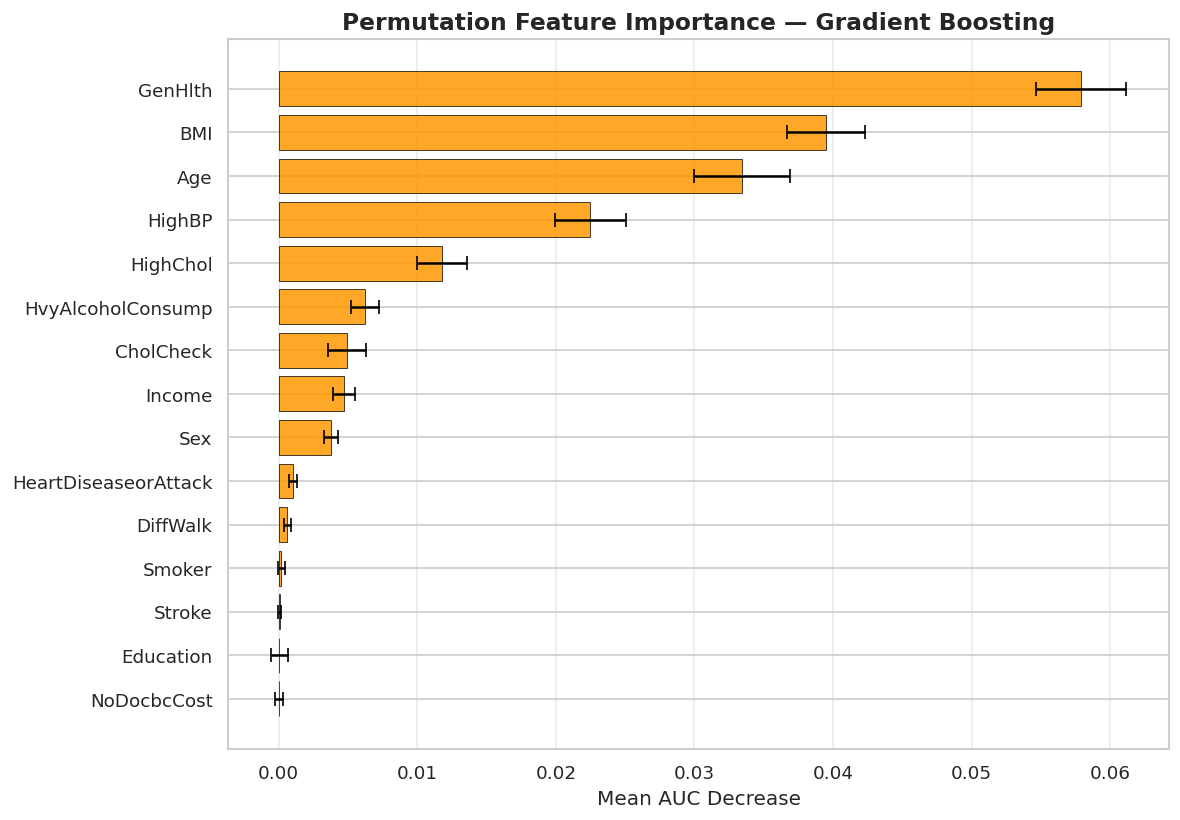

In [57]:
# Permutation Importance Plot
plt.figure(figsize=(10, 7))
top = pfi_df.head(15)
plt.barh(top['Feature'], top['Importance'],
         xerr=top['Std'], color='#FF9800', alpha=0.85,
         edgecolor='black', linewidth=0.5,
         error_kw={'elinewidth': 1.5, 'capsize': 4})
plt.xlabel('Mean AUC Decrease', fontsize=12)
plt.title('Permutation Feature Importance — Gradient Boosting',
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig('gb_14_permutation_importance.png', bbox_inches='tight')
plt.show()

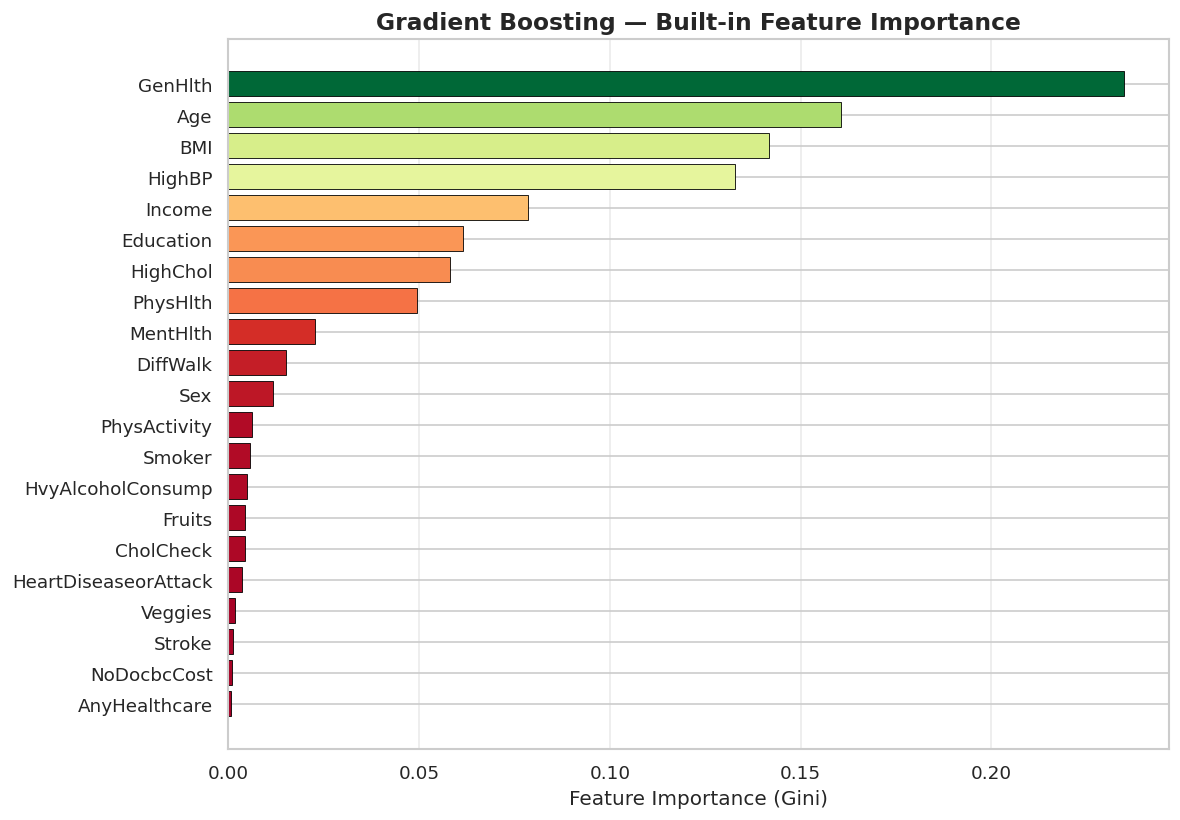

In [58]:
# Built-in Feature Importance (Gini)
fi_gb = pd.DataFrame({
    'Feature'    : feature_names,
    'Importance' : gb_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(fi_gb['Feature'], fi_gb['Importance'],
         color=plt.cm.RdYlGn(fi_gb['Importance'] / fi_gb['Importance'].max()),
         edgecolor='black', linewidth=0.5)
plt.xlabel('Feature Importance (Gini)', fontsize=12)
plt.title('Gradient Boosting — Built-in Feature Importance',
          fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig('gb_15_builtin_importance.png', bbox_inches='tight')
plt.show()

---
## XAI Technique 4 — Partial Dependence Plots (PDP)

Top features for PDP: ['GenHlth', 'BMI', 'Age', 'PhysHlth', 'MentHlth', 'Education']


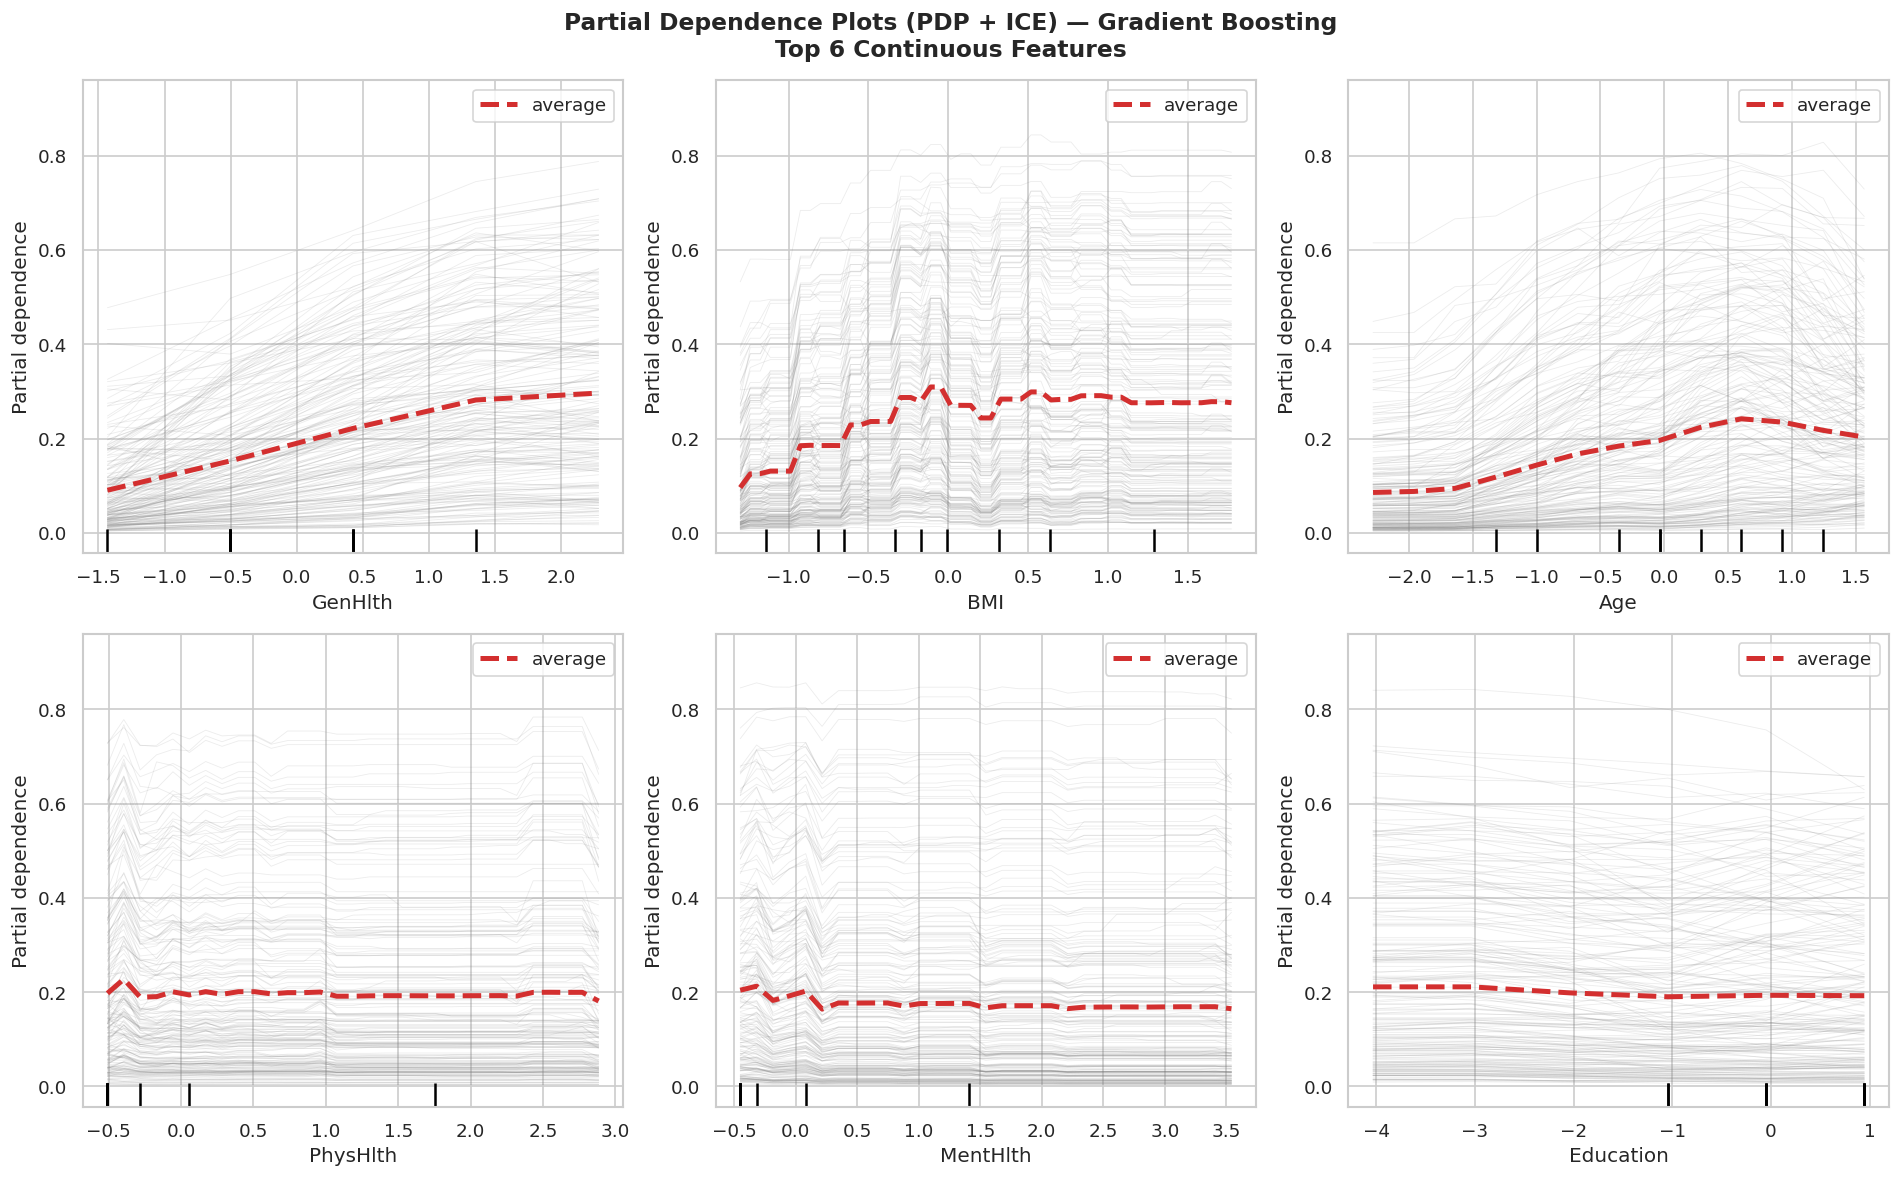

In [59]:
# continuous features بس للـ PDP
continuous_features = ['GenHlth', 'BMI', 'Age', 'PhysHlth', 'MentHlth', 'Education']
top_feat_idx = [feature_names.index(f) for f in continuous_features]
print(f'Top features for PDP: {continuous_features}')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
PartialDependenceDisplay.from_estimator(
    gb_model,
    X_test_df.values,
    features          = top_feat_idx,
    feature_names     = feature_names,
    kind              = 'both',
    subsample         = 200,
    percentiles       = (0.05, 0.95),
    grid_resolution   = 50,
    ax                = axes.flatten(),
    ice_lines_kw      = {'color': 'grey', 'alpha': 0.15, 'linewidth': 0.5},
    pd_line_kw        = {'color': '#D32F2F', 'linewidth': 3}
)
plt.suptitle('Partial Dependence Plots (PDP + ICE) — Gradient Boosting\nTop 6 Continuous Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('gb_16_pdp.png', bbox_inches='tight')
plt.show()

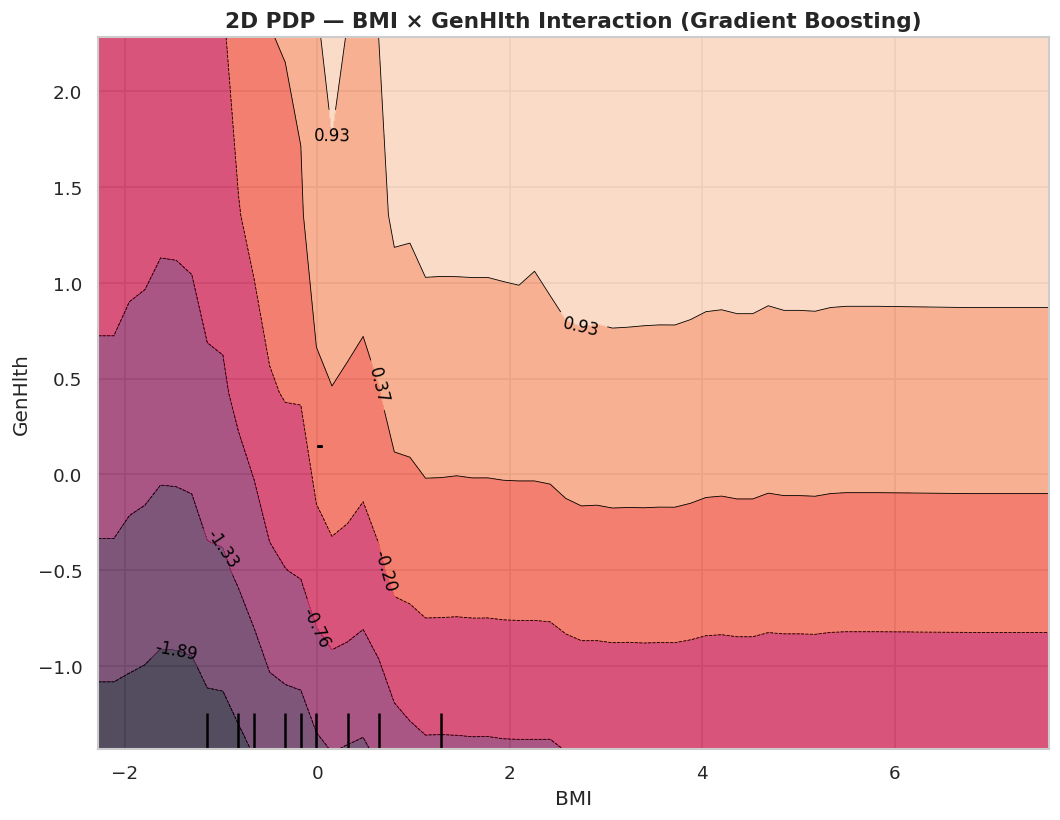

In [60]:
# 2D PDP Interaction
bmi_idx     = feature_names.index('BMI')
genhlth_idx = feature_names.index('GenHlth')

fig, ax = plt.subplots(figsize=(9, 7))
PartialDependenceDisplay.from_estimator(
    gb_model, X_test_df.values,
    features=[(bmi_idx, genhlth_idx)],
    feature_names=feature_names,
    kind='average', ax=ax
)
plt.title('2D PDP — BMI × GenHlth Interaction (Gradient Boosting)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gb_17_pdp_2d.png', bbox_inches='tight')
plt.show()

---
##  6. Final Results

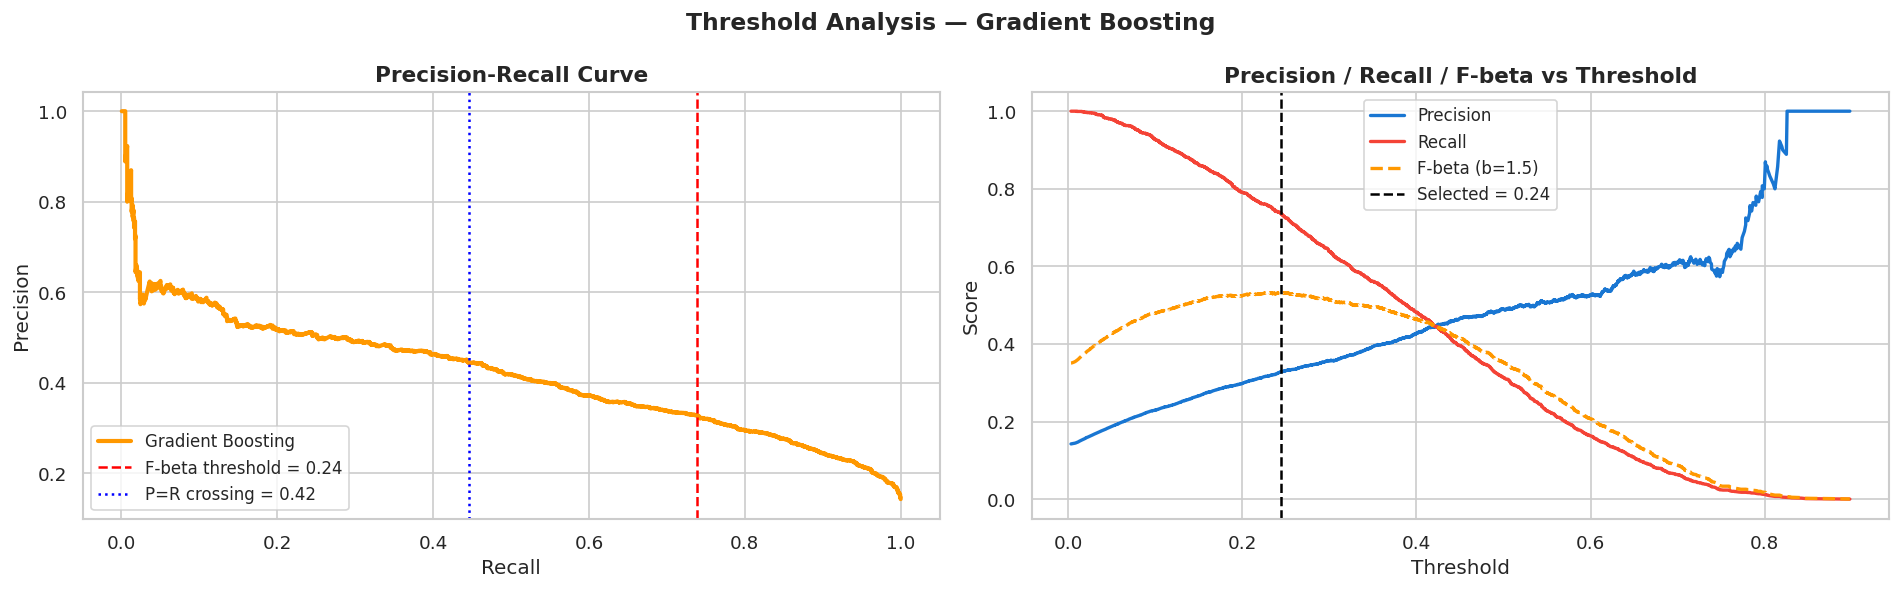

In [61]:
# Precision-Recall curve with both threshold markers
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(recalls[:-1], precisions[:-1], color="#FF9800", linewidth=2.5,
             label="Gradient Boosting")
axes[0].axvline(recalls[best_idx], color="red", linestyle="--", linewidth=1.5,
                label=f"F-beta threshold = {best_threshold:.2f}")
axes[0].axvline(recalls[cross_idx], color="blue", linestyle=":", linewidth=1.5,
                label=f"P=R crossing = {cross_threshold:.2f}")
axes[0].set_xlabel("Recall", fontsize=12)
axes[0].set_ylabel("Precision", fontsize=12)
axes[0].set_title("Precision-Recall Curve", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=10)

axes[1].plot(thresholds, precisions[:-1], color="#1976D2", linewidth=2, label="Precision")
axes[1].plot(thresholds, recalls[:-1],    color="#F44336", linewidth=2, label="Recall")
axes[1].plot(thresholds, fbeta_scores[:-1], color="#FF9800", linewidth=2,
             linestyle="--", label=f"F-beta (b={beta})")
axes[1].axvline(best_threshold, color="black", linestyle="--", linewidth=1.5,
                label=f"Selected = {best_threshold:.2f}")
axes[1].set_xlabel("Threshold", fontsize=12)
axes[1].set_ylabel("Score", fontsize=12)
axes[1].set_title("Precision / Recall / F-beta vs Threshold", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=10)

plt.suptitle("Threshold Analysis — Gradient Boosting", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("gb_18_threshold_analysis.png", bbox_inches="tight")
plt.show()


In [62]:
print('=' * 52)
print('  GRADIENT BOOSTING — FINAL PERFORMANCE SUMMARY')
print('=' * 52)
print(f'  Accuracy  : {gb_acc:.4f}')
print(f'  AUC-ROC   : {gb_auc:.4f}')
print(f'  F1-Score  : {gb_f1:.4f}')
print(f'  Precision : {gb_prec:.4f}')
print(f'  Recall    : {gb_rec:.4f}')
print('=' * 52)
print()

print('=' * 52)

  GRADIENT BOOSTING — FINAL PERFORMANCE SUMMARY
  Accuracy  : 0.7470
  AUC-ROC   : 0.8180
  F1-Score  : 0.4547
  Precision : 0.3284
  Recall    : 0.7387

